The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


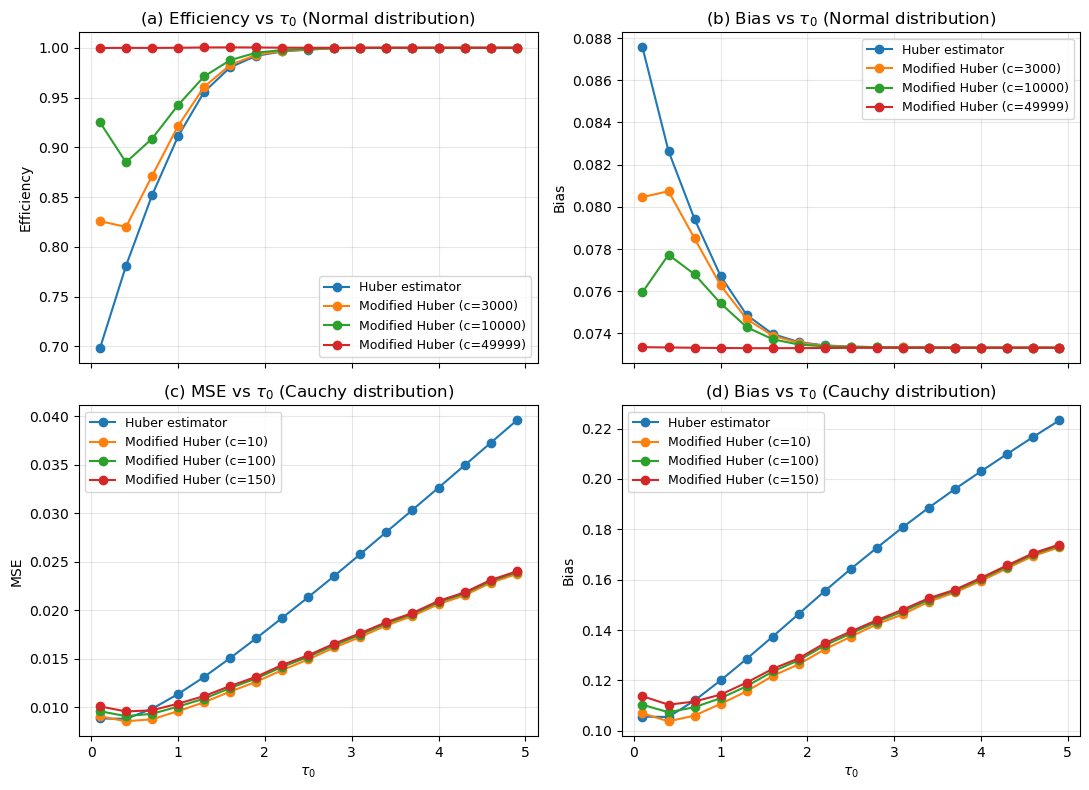

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===================== file mapping =====================
normal_files = {
    3000:  "eff_bias_summary_c3000.csv",
    10000: "eff_bias_summary_c10000.csv",
    49999: "eff_bias_summaryc49999.csv",  # rename if needed
}

cauchy_files = {
    10:  "mse_bias_summary_c10.csv",
    100:  "mse_bias_summaryc_100.csv",
    150: "mse_bias_summaryc_150.csv",
}

def read_sorted(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df.sort_values("tau").reset_index(drop=True)

normal_dfs = {c: read_sorted(p) for c, p in normal_files.items()}
cauchy_dfs = {c: read_sorted(p) for c, p in cauchy_files.items()}

# Huber 在不同 c 文件里相同，所以取最小 c 的作为 baseline
base_normal = normal_dfs[min(normal_dfs)]
base_cauchy = cauchy_dfs[min(cauchy_dfs)]

out_dir = Path(".")
out_dir.mkdir(parents=True, exist_ok=True)

# ===================== Combined figure (2x2) =====================
fig, ax = plt.subplots(2, 2, figsize=(11, 8), sharex="col")

# (a) Normal: Efficiency
ax[0, 0].plot(base_normal["tau"], base_normal["Huber_eff"], marker="o", label="Huber estimator")
for c in sorted(normal_dfs):
    ax[0, 0].plot(normal_dfs[c]["tau"], normal_dfs[c]["MoHuber_eff"], marker="o",
                  label=f"Modified Huber (c={c})")
ax[0, 0].set_ylabel("Efficiency")
ax[0, 0].set_title("(a) Efficiency vs $\\tau_0$ (Normal distribution)")
ax[0, 0].grid(True, alpha=0.3)
ax[0, 0].legend(fontsize=9)

# (b) Normal: Bias
ax[0, 1].plot(base_normal["tau"], base_normal["Huber_Bias"], marker="o", label="Huber estimator")
for c in sorted(normal_dfs):
    ax[0, 1].plot(normal_dfs[c]["tau"], normal_dfs[c]["MoHuber_Bias"], marker="o",
                  label=f"Modified Huber (c={c})")
ax[0, 1].set_ylabel("Bias")
ax[0, 1].set_title("(b) Bias vs $\\tau_0$ (Normal distribution)")
ax[0, 1].grid(True, alpha=0.3)
ax[0, 1].legend(fontsize=9)

# (c) Cauchy: MSE
ax[1, 0].plot(base_cauchy["tau"], base_cauchy["Huber_MSE"], marker="o", label="Huber estimator")
for c in sorted(cauchy_dfs):
    ax[1, 0].plot(cauchy_dfs[c]["tau"], cauchy_dfs[c]["MoHuber_MSE"], marker="o",
                  label=f"Modified Huber (c={c})")
ax[1, 0].set_xlabel(r"$\tau_0$")
ax[1, 0].set_ylabel("MSE")
ax[1, 0].set_title("(c) MSE vs $\\tau_0$ (Cauchy distribution)")
ax[1, 0].grid(True, alpha=0.3)
ax[1, 0].legend(fontsize=9)

# (d) Cauchy: Bias
ax[1, 1].plot(base_cauchy["tau"], base_cauchy["Huber_Bias"], marker="o", label="Huber estimator")
for c in sorted(cauchy_dfs):
    ax[1, 1].plot(cauchy_dfs[c]["tau"], cauchy_dfs[c]["MoHuber_Bias"], marker="o",
                  label=f"Modified Huber (c={c})")
ax[1, 1].set_xlabel(r"$\tau_0$")
ax[1, 1].set_ylabel("Bias")
ax[1, 1].set_title("(d) Bias vs $\\tau_0$ (Cauchy distribution)")
ax[1, 1].grid(True, alpha=0.3)
ax[1, 1].legend(fontsize=9)

fig.tight_layout()

# ===== save as ONE EPS (single page) =====
fig.savefig(out_dir / "modhuber_2x2_abcd.eps", format="eps",
            bbox_inches="tight", pad_inches=0.02)
fig.savefig(out_dir / "modhuber_2x2_abcd.png", dpi=300,
            bbox_inches="tight", pad_inches=0.02)

plt.show()
